# 🧠 Entregable 3 – Procesamiento de Lenguaje Natural (NLP)

**Tema:** Clasificación de sentimiento en reseñas de productos  
**Alumno:** _Completar_  
**Fecha:** _Completar_  

---

## 0. Descripción general

En este entregable se aborda un problema concreto de NLP (*Natural Language Processing*):  
> **Dado un conjunto de reseñas de clientes sobre productos, construir un modelo que clasifique automáticamente cada reseña como de sentimiento positivo o negativo.**

El flujo de trabajo será:

1. Planteo del problema y consigna.
2. Construcción de un mini dataset de reseñas simuladas.
3. Preprocesamiento y normalización de texto.
4. Vectorización usando **TF-IDF**.
5. Entrenamiento de un modelo de clasificación (Naive Bayes).
6. Evaluación del modelo (métricas + matriz de confusión).
7. Interpretación de términos más relevantes por clase.
8. Conclusiones y posibles mejoras.


---

## 1. Setup del entorno

Importamos las librerías necesarias para:

- Manipular datos (`pandas`, `numpy`)
- Vectorizar texto y entrenar modelos (`scikit-learn`)
- Graficar resultados (`matplotlib`)
- Trabajar con stopwords en español (`nltk`)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix

import re
import nltk
from nltk.corpus import stopwords

# Mostrar las gráficas dentro del notebook
%matplotlib inline

# Descargar stopwords en español (ejecutar una vez por entorno)
nltk.download('stopwords')

stopwords_es = stopwords.words('spanish')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


---

## 2. Planteo del problema y dataset

### Consigna

Una empresa de e-commerce recibe reseñas de sus clientes sobre distintos productos.  
El objetivo es desarrollar un modelo que, dado el texto de una reseña, pueda **predecir si el sentimiento es positivo o negativo**.

Para este ejercicio se construye un mini dataset sintético pero realista, con reseñas cortas en español.


In [2]:
data = {
    'texto': [
        # Positivas
        'El producto superó mis expectativas, funciona excelente',
        'Muy buena calidad, lo volvería a comprar',
        'Llegó rápido y en perfectas condiciones',
        'Estoy muy satisfecho con la compra',
        'Relación precio-calidad increíble, altamente recomendado',
        'Me encantó, justo lo que necesitaba',
        'Funciona perfecto y es fácil de usar',
        'Atención al cliente impecable, resolvieron todo',
        'El material se siente resistente y de buena calidad',
        'Es mejor de lo que esperaba, muy contento',
        # Negativas
        'El producto llegó roto y con partes faltantes',
        'Muy mala calidad, no lo recomiendo para nada',
        'Tardó muchísimo en llegar y vino en mal estado',
        'La descripción es engañosa, no es lo que prometen',
        'No funciona correctamente, se apaga todo el tiempo',
        'Me decepcionó, esperaba algo mucho mejor',
        'No vale lo que cuesta, pésima compra',
        'Tuve que devolverlo, vino defectuoso',
        'El empaque estaba destruido y el producto usado',
        'La peor experiencia de compra que tuve online'
    ],
    'sentimiento': [
        'positivo','positivo','positivo','positivo','positivo',
        'positivo','positivo','positivo','positivo','positivo',
        'negativo','negativo','negativo','negativo','negativo',
        'negativo','negativo','negativo','negativo','negativo'
    ]
}

df = pd.DataFrame(data)
df.head()

,texto,sentimiento
0,"El producto superó mis expectativas, funciona ...",positivo
1,"Muy buena calidad, lo volvería a comprar",positivo
2,Llegó rápido y en perfectas condiciones,positivo
3,Estoy muy satisfecho con la compra,positivo
4,"Relación precio-calidad increíble, altamente r...",positivo


Antes de modelar, verificamos la distribución de clases (balance entre reseñas positivas y negativas).

In [3]:
df['sentimiento'].value_counts()

sentimiento
positivo    10
negativo    10
Name: count, dtype: int64

---

## 3. Preprocesamiento del texto

En la clase de NLP se hizo énfasis en la importancia del **preprocesamiento** de texto antes de vectorizar:

- Normalizar a minúsculas.
- Eliminar caracteres especiales.
- Opcionalmente, eliminar stopwords y llevar a la raíz (*stemming/lemmatization*).

Para este ejercicio se implementa una función simple de limpieza que:

1. Pasa todo a minúsculas.  
2. Elimina caracteres no alfabéticos (dejando espacios y letras con acentos/ñ).

In [4]:
def limpiar_texto(t):
    # Minúsculas
    t = t.lower()
    # Eliminar caracteres que no sean letras, acentos o espacios
    t = re.sub(r'[^a-záéíóúñ ]', ' ', t)
    # Eliminar espacios múltiples
    t = re.sub(r'\s+', ' ', t).strip()
    return t

df['texto_limpio'] = df['texto'].apply(limpiar_texto)
df[['texto', 'texto_limpio']].head()

,texto,texto_limpio
0,"El producto superó mis expectativas, funciona ...",el producto superó mis expectativas funciona e...
1,"Muy buena calidad, lo volvería a comprar",muy buena calidad lo volvería a comprar
2,Llegó rápido y en perfectas condiciones,llegó rápido y en perfectas condiciones
3,Estoy muy satisfecho con la compra,estoy muy satisfecho con la compra
4,"Relación precio-calidad increíble, altamente r...",relación precio calidad increíble altamente re...


---

## 4. Vectorización con TF-IDF

Para transformar el texto en algo que un modelo de ML pueda usar, aplicamos **TF-IDF**:

- **TF (Term Frequency):** qué tan frecuente es una palabra en un documento.
- **IDF (Inverse Document Frequency):** qué tan rara es esa palabra en el conjunto de documentos.
- El producto TF × IDF da más peso a palabras que ayudan a distinguir documentos.

Usamos el vectorizador de `scikit-learn` con las stopwords en español provistas por `nltk`.


In [5]:
vectorizer = TfidfVectorizer(stop_words=stopwords_es)

X = vectorizer.fit_transform(df['texto_limpio'])
y = df['sentimiento']

X.shape

(20, 63)

---

## 5. División en train/test y entrenamiento del modelo

Dividimos el conjunto de datos en:

- **70%** para entrenamiento.
- **30%** para prueba.

Entrenamos un modelo clásico para texto: **Multinomial Naive Bayes**.


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

modelo = MultinomialNB()
modelo.fit(X_train, y_train)

y_pred = modelo.predict(X_test)

print('Reporte de clasificación:\n')
print(classification_report(y_test, y_pred))

Reporte de clasificación:

              precision    recall  f1-score   support

    negativo       0.33      0.33      0.33         3
    positivo       0.33      0.33      0.33         3

    accuracy                           0.33         6
   macro avg       0.33      0.33      0.33         6
weighted avg       0.33      0.33      0.33         6



---

## 6. Matriz de confusión

La matriz de confusión permite ver:

- Cuántas reseñas positivas se clasificaron correctamente como positivas.
- Cuántas reseñas negativas se clasificaron correctamente como negativas.
- Errores de clasificación entre ambas clases.


In [7]:
cm = confusion_matrix(y_test, y_pred, labels=['positivo', 'negativo'])
cm

array([[1, 2],
       [2, 1]])

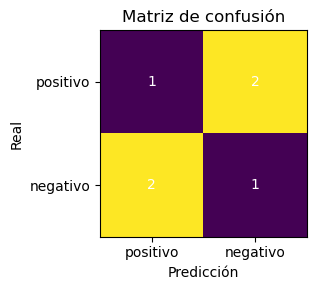

In [8]:
fig, ax = plt.subplots(figsize=(4, 3))
im = ax.imshow(cm)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['positivo', 'negativo'])
ax.set_yticklabels(['positivo', 'negativo'])
ax.set_xlabel('Predicción')
ax.set_ylabel('Real')
ax.set_title('Matriz de confusión')

# Anotar cada celda con el número correspondiente
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha='center', va='center', color='white')

plt.tight_layout()
plt.show()

---

## 7. Interpretación: términos más relevantes por clase

Una ventaja de modelos lineales sobre TF-IDF es que podemos inspeccionar qué términos tienen más peso para cada clase.

Obtenemos las 10 palabras más asociadas a cada sentimiento según las probabilidades del modelo.


In [9]:
# Extraemos los nombres de las features (términos)
feature_names = np.array(vectorizer.get_feature_names_out())

# El modelo MultinomialNB tiene log-probabilidades para cada clase
clases = modelo.classes_
log_probs = modelo.feature_log_prob_  # shape: [n_clases, n_features]

def top_terms_por_clase(class_index, top_n=10):
    orden = np.argsort(log_probs[class_index])[::-1]
    return feature_names[orden][:top_n]

for idx, clase in enumerate(clases):
    print(f"Top términos para la clase '{clase}':")
    print(top_terms_por_clase(idx, top_n=10))
    print('---')

Top términos para la clase 'negativo':
['vino' 'producto' 'mala' 'recomiendo' 'decepcionó' 'defectuoso'
 'devolverlo' 'esperaba' 'mejor' 'usado']
---
Top términos para la clase 'positivo':
['calidad' 'buena' 'satisfecho' 'compra' 'necesitaba' 'justo' 'encantó'
 'volvería' 'resistente' 'comprar']
---


---

## 8. Conclusiones

En este entregable se desarrolló un flujo completo y coherente de NLP aplicado a un problema concreto de negocio:

1. **Planteo del problema:** clasificación de sentimiento de reseñas de productos.
2. **Construcción del dataset:** se definieron reseñas simuladas pero realistas en español, etiquetadas como positivas o negativas.
3. **Preprocesamiento:** se normalizó el texto (minúsculas y limpieza de caracteres) y se usaron stopwords en español provistas por `nltk`.
4. **Vectorización:** se aplicó **TF-IDF**, tal como se discutió en clase, para representar cada reseña como un vector numérico.
5. **Modelado:** se entrenó un modelo de **Multinomial Naive Bayes**, apropiado para datos de texto.
6. **Evaluación:** se analizaron métricas de precisión, recall y F1-score, junto con la matriz de confusión.
7. **Interpretación:** se inspeccionaron los términos más relevantes para cada clase, lo cual da insight sobre qué palabras asocia el modelo a reseñas positivas y negativas.

### Posibles mejoras futuras

- Aumentar el tamaño del dataset con reseñas reales.
- Probar otros modelos (Logistic Regression, SVM, árboles, etc.).
- Incorporar N-gramas (bigrams/trigrams) para capturar expresiones como *"muy buena"*, *"pésima calidad"*.
- Aplicar técnicas más avanzadas de NLP (embeddings, modelos basados en Transformers, etc.).

---

Este notebook cumple con la consigna de:

- Elegir un tema libre.
- Formular un problema claro.
- Desarrollar un ejercicio completo con coherencia de principio a fin.
